# Analyzing Gender Bias in Job Descriptions

## Introduction

In this exercise, we will look at gender bias in job descriptions made by AI. We will use a small language model to create job descriptions and then check if they show any gender bias.

In [1]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer
import nltk
from nltk.tokenize import word_tokenize
import pandas as pd
import matplotlib.pyplot as plt
import warnings


# Download necessary NLTK data
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

True

## Step 2: Load the AI model

We will use a pre-trained DistilGPT2 model, which is smaller and faster:

In [2]:
# Ignore FutureWarnings
warnings.filterwarnings('ignore', category=FutureWarning)

model_name = "distilgpt2"
model = AutoModelForCausalLM.from_pretrained(model_name)
tokenizer = AutoTokenizer.from_pretrained(model_name)

config.json:   0%|          | 0.00/762 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/353M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

## Step 3: Prepare job titles

Let's make a list of job titles:

In [2]:
job_titles = [
    "Software Engineer", "Nurse", "CEO", "Teacher", "Data Scientist",
    "Human Resources Manager", "Mechanical Engineer", "Marketing Specialist"
]

## Step 4: Create a function to generate job descriptions

In [3]:
def generate_job_description(job_title):
    prompt = f"Job Description for {job_title}:"
    input_ids = tokenizer.encode(prompt, return_tensors="pt")
    
    attention_mask = torch.ones(input_ids.shape, dtype=torch.long)
    pad_token_id = tokenizer.pad_token_id if tokenizer.pad_token_id is not None else tokenizer.eos_token_id
    
    output = model.generate(
        input_ids,
        max_length=200,
        num_return_sequences=1,
        no_repeat_ngram_size=2,
        attention_mask=attention_mask,
        pad_token_id=pad_token_id
    )
    return tokenizer.decode(output[0], skip_special_tokens=True)

## Step 5: Generate job descriptions

In [5]:
job_descriptions = {title: generate_job_description(title) for title in job_titles}

# Let's look at one of the generated descriptions
print(job_descriptions["Software Engineer"])

Job Description for Software Engineer:

The Software Engineering Team is a team of engineers who work on software engineering, software development, and software design. They work in the software industry, including software and hardware engineering.
We are a community of software engineers, engineers and engineers. We are passionate about the quality of the work we do and the benefits of our work. Our team is dedicated to helping the community understand the importance of open source software. The team has a wide range of skills and expertise. In addition to being a member of a technical team, we are also a part of an open-source community.


## Step 6: Analyze gender bias

First, we'll make lists of words that are typically associated with male or female genders:

In [10]:
male_words = ["he", "him", "his", "man", "men", "male", "masculine"]
female_words = ["she", "her", "hers", "woman", "women", "female", "feminine"]

def count_gendered_words(text):
    words = word_tokenize(text.lower())
    male_count = sum(word in male_words for word in words)
    female_count = sum(word in female_words for word in words)
    return male_count, female_count

results = []
for title, description in job_descriptions.items():
    male_count, female_count = count_gendered_words(description)
    total_words = len(word_tokenize(description))
    results.append({
        "Job Title": title,
        "Male Words": male_count,
        "Female Words": female_count,
        "Total Words": total_words,
        "Male Ratio": male_count / total_words,
        "Female Ratio": female_count / total_words
    })

## Step 7: Visualize the results

                 Job Title  Male Words  Female Words  Total Words  Male Ratio  \
0        Software Engineer           0             0          119    0.000000   
1                    Nurse           0             3           98    0.000000   
2                      CEO           0             0          134    0.000000   
3                  Teacher           1             3          154    0.006494   
4           Data Scientist           0             0          154    0.000000   
5  Human Resources Manager           0             0          137    0.000000   
6      Mechanical Engineer           4             0          110    0.036364   
7     Marketing Specialist           0             0           49    0.000000   

   Female Ratio  
0      0.000000  
1      0.030612  
2      0.000000  
3      0.019481  
4      0.000000  
5      0.000000  
6      0.000000  
7      0.000000  


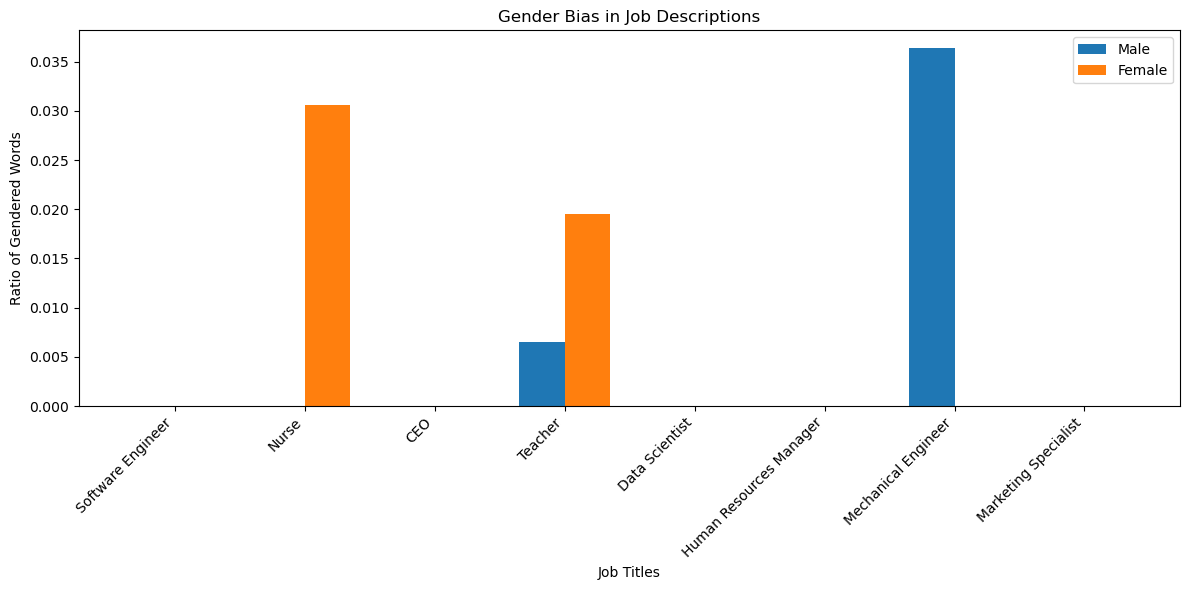

In [7]:
df = pd.DataFrame(results)
print(df)

plt.figure(figsize=(12, 6))
bar_width = 0.35
index = range(len(job_titles))

plt.bar(index, df["Male Ratio"], bar_width, label="Male")
plt.bar([i + bar_width for i in index], df["Female Ratio"], bar_width, label="Female")

plt.xlabel("Job Titles")
plt.ylabel("Ratio of Gendered Words")
plt.title("Gender Bias in Job Descriptions")
plt.xticks([i + bar_width/2 for i in index], job_titles, rotation=45, ha="right")
plt.legend()
plt.tight_layout()
plt.show()

## Step 8: Interpret the results

Now, let's think about these questions:

1. Which jobs have the most gender bias in their descriptions?
2. Are there any jobs with more neutral descriptions?
3. What specific words or phrases might be causing gender bias?

1. Nurse (Female Words=3), Teacher (Male Words=1, Female Words=3), Mechanical Engineer (Male Words=4).
2. All except the ones mentioned in point 1 are with more neutral descriptions, because the use words 'we' and 'they'.
3. The following might cause gender bias:
 - Gendered Job Titles (Policeman, fireman, chairman, stewardess instead of: police officer, firefighter, chairperson/chair, flight attendant);
 - Assumptive Pronouns (Using "he" or "she" as the default for unknown or generic individualsinstead of "they" (singular), or rephrasing to avoid pronouns);
 - Stereotypical Descriptions ("Bossy" for women, "assertive" for men; "Emotional" for women, "rational" for men);
 - Terms That Diminish or Infantilize (Calling adult women "girls" or "ladies" in professional contexts; Using "guys" to refer to mixed-gender groups);
 - Phrases That Assume Traditional Roles ("Working mother" (rarely "working father"); "Man up," "grow a pair," "throw like a girl");
 - Default Male Language ("Mankind" instead of "humankind" or "people"; "Man-made" instead of "artificial" or "human-made");
 - Unnecessary Gender Markers ("Female doctor," "male nurse").

## Step 9: Suggest ways to reduce bias

Based on our analysis, how can we make job descriptions less biased? Here are some ideas:

1. Use gender-neutral terms
2. Balance the use of pronouns
3. Review job requirements for hidden bias

1. and 2. We can modify job description generation function with (as implemented below):
   - prompt enhancement "Please use gender-neutral language and avoid stereotypes.";
   - manual gender-biased words replacements;
   - manual balance the use of pronouns;
We'll avoid biased words in this way. However the job description might be lexically not correct. To enhance job description generation
with the current model we might use a grammar correction library "language_tool_python" to automatically fix agreement
and phrasing after pronoun replacement.

Also, generated results might be  way better with another libraries, e.g. "gp2" or newer.

In [14]:
import re

def balance_pronouns(text):
    corrections = {
        r'\bthey is\b': 'they are',
        r'\bthey was\b': 'they were',
        r'\bthey has\b': 'they have',
        r'\bthey does\b': 'they do',
        r"\bthey's\b": 'they are',
    }

    def preserve_case(match, replacement):
        original = match.group(0)
        # All uppercase
        if original.isupper():
            return replacement.upper()
        # Capitalized
        elif original[0].isupper():
            return replacement.capitalize()
        # Lowercase
        else:
            return replacement

    for pattern, replacement in corrections.items():
        text = re.sub(
            pattern,
            lambda match: preserve_case(match, replacement),
            text,
            flags=re.IGNORECASE
        )
    return text

def generate_job_description_new(job_title):
    prompt = f"Job Description for {job_title}: Please use gender-neutral language and avoid stereotypes."
    input_ids = tokenizer.encode(prompt, return_tensors="pt")
    
    attention_mask = torch.ones(input_ids.shape, dtype=torch.long)
    pad_token_id = tokenizer.pad_token_id if tokenizer.pad_token_id is not None else tokenizer.eos_token_id
    
    output = model.generate(
        input_ids,
        max_length=200,
        num_return_sequences=1,
        no_repeat_ngram_size=2,
        attention_mask=attention_mask,
        pad_token_id=pad_token_id
    )
    description = tokenizer.decode(output[0], skip_special_tokens=True)
    
    # Remove the prompt from the beginning of the output, if present
    if description.startswith(prompt):
        description = description[len(prompt):].lstrip()
    
    # Gendered terms and their neutral replacements
    gendered_terms = {
        "he": "they", "him": "them", "his": "their", "man": "person", "men": "people", "male": "individual",
        "masculine": "neutral", "she": "they", "her": "them", "hers": "theirs", "woman": "person", 
        "women": "people", "female": "individual", "feminine": "neutral"
    }
    def replace_gendered(match):
        word = match.group(0)
        replacement = gendered_terms[word.lower()]
        if word.isupper():
            return replacement.upper()
        elif word[0].isupper():
            return replacement.capitalize()
        else:
            return replacement
        
    pattern = re.compile(r'\b(' + '|'.join(gendered_terms.keys()) + r')\b', re.IGNORECASE)

    description = pattern.sub(replace_gendered, description)
    description_balanced = balance_pronouns(description)
    return description_balanced.strip()

In [15]:
job_descriptions_new = {title: generate_job_description_new(title) for title in job_titles}

In [17]:
results_new = []
for title, description in job_descriptions_new.items():
    male_count, female_count = count_gendered_words(description)
    total_words = len(word_tokenize(description))
    results_new.append({
        "Job Title": title,
        "Male Words": male_count,
        "Female Words": female_count,
        "Total Words": total_words,
        "Male Ratio": male_count / total_words,
        "Female Ratio": female_count / total_words
    })

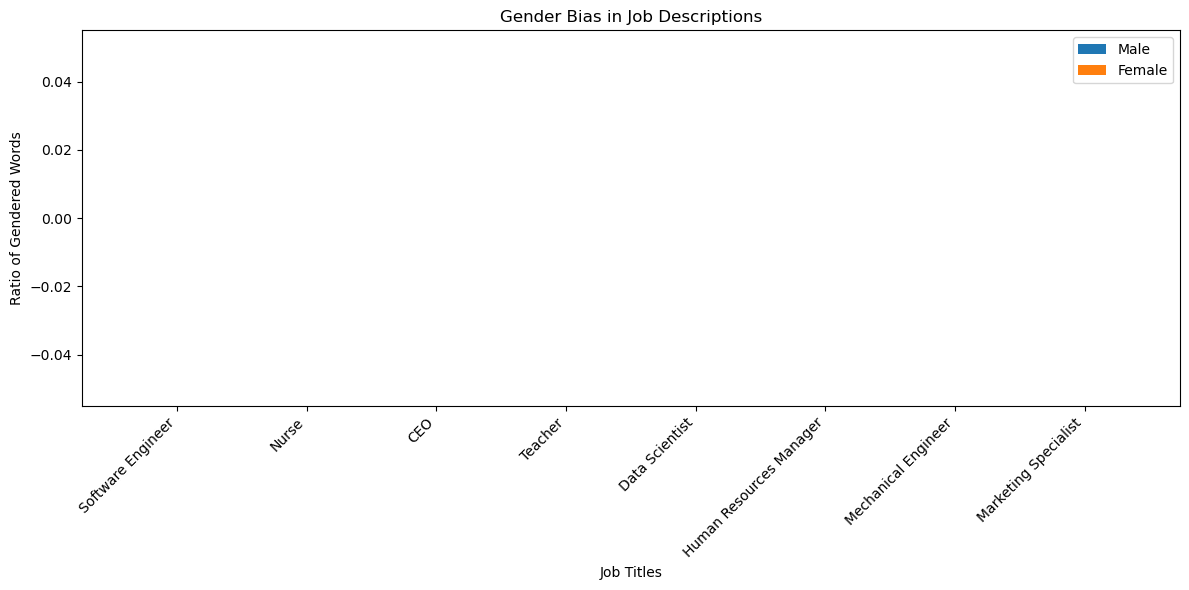

In [23]:
df = pd.DataFrame(results_new)

plt.figure(figsize=(12, 6))
bar_width = 0.35
index = range(len(job_titles))

plt.bar(index, df["Male Ratio"], bar_width, label="Male")
plt.bar([i + bar_width for i in index], df["Female Ratio"], bar_width, label="Female")

plt.xlabel("Job Titles")
plt.ylabel("Ratio of Gendered Words")
plt.title("Gender Bias in Job Descriptions")
plt.xticks([i + bar_width/2 for i in index], job_titles, rotation=45, ha="right")
plt.legend()
plt.tight_layout()
plt.show()

3. Review job requirements for hidden bias

Let's generate job requirements for each title and analyze them

In [20]:
def generate_job_requirements(job_title):
    prompt = f"Job Requirements for {job_title}:"
    input_ids = tokenizer.encode(prompt, return_tensors="pt")
    
    attention_mask = torch.ones(input_ids.shape, dtype=torch.long)
    pad_token_id = tokenizer.pad_token_id if tokenizer.pad_token_id is not None else tokenizer.eos_token_id
    
    output = model.generate(
        input_ids,
        max_length=200,
        num_return_sequences=1,
        no_repeat_ngram_size=2,
        attention_mask=attention_mask,
        pad_token_id=pad_token_id
    )
    return tokenizer.decode(output[0], skip_special_tokens=True)

In [22]:
job_requirements = {title: generate_job_requirements(title) for title in job_titles}

for item in job_titles:
    print(item, job_requirements[item])

Software Engineer Job Requirements for Software Engineer:

The following are the requirements for software engineer:1) The following requirements are for the software engineering team:2) Software engineering and development of software development software.
Software engineering is a technical skill that requires a degree in computer science or computer engineering. Software engineers are required to be able to work on software projects that are not related to software design. The software engineers must be proficient in the design of the project and the development and implementation of a software project.2)(1)(2). Software engineer must have a bachelor's degree from the University of California, Berkeley.3)
A bachelor of in Computer Science or Computer Engineering is an engineer who has been a computer engineer for over 30 years. In addition to the following, the required degree is required for a master's in software and software management.4) A master of computer design is also requi

1. Software Engineer has the following biases:
    - Educational bias (Specific University Requirement = University of California, Berkeley);
    - Age bias (“...has been a computer engineer for over 30 years.” This could discourage younger
      applicants and is not typical for most software engineering roles);
2. Nurse has the following bias:
   - Professional bias (“A nurse must work for the same profession as a physician.” - could be interpreted as implying
     nurses are subordinate to physicians, which may reinforce professional hierarchy bias);
3. CEO has the following biases:
   - Professional bias (mentions “technology,” “engineering,” and “technical aspects.” This may unintentionally exclude
     candidates with strong leadership, business, or financial backgrounds who could be effective CEOs, especially in
     non-technical or multi-disciplinary organizations);
   - Age bias (“If the employee is a senior employee…”. This is not inherently ageist, but prefer older candidates or
     excessive years of experience, which could discourage younger, qualified applicants);
4. Teacher - no potential biases in job requirements (assuming that the teacher is a English language teacher);
5. Data Scientist - no potential biases in job requirements;
6. The Human Resource Manager - no potential biases in job requirements;
7. Mechanical Engineer has the following biases:
   - Educational bias (requiring degrees from specific universities (e.g., University of California, Berkeley) can be
     exclusionary and may introduce bias against qualified candidates from other institutions or countries);
   - Professional bias (The requirements mix mechanical, electrical, and computer engineering/science degrees, which may
     not be relevant for all mechanical engineering roles);
9. Marketing Specialist - no job requirements at all.

## Step 10: Reflection

Think about these questions:

1. What are the limits of this method for analyzing gender bias?
2. How can we improve this analysis to get more accurate results?
3. What ethical issues should we think about when using AI to generate job descriptions?

1. Gender analyzing limits in the method:
    - detects only overt gendered words (it cannot detect more subtle or implicit gender bias,
     such as gender-coded adjectives (e.g. “assertive,” “nurturing”) or stereotypical role descriptions);
    - ignores context (words like “man” in “human” or “her” in “herb” may be counted incorrectly);
    - doesn't account for synonyms or gendered phrases (many gendered phrases or synonyms (e.g. “chairman”,
      “stewardess”, “guys”, “ladies”) are not included in lists). It won’t catch gendered job titles or phrases unless explicitly listed;
    - ignores pronoun use in plural or neutral contexts (“they”, “their”);
    - no understanding of sentence structure or meaning (it may count words that are not actually contributing to bias);
    - doesn't detect gender-coded language (“dominant”, “competitive”, “supportive” or “collaborative” can be gender-coded and influence perception);
    - no detection of implied or structural bias (the method cannot detect if a job description implies a gender preference through
      expectations or requirements (e.g. “must be able to work long hours” may discourage women with caregiving responsibilities).
2. For manual bias detection we can't implement handling in the code points mentioned above.
   Also there are text classification models specifically designed for bias detection, including gender bias, racial bias, and
   other forms of discriminatory or non-inclusive language. So, we can analyze the text using models.
3. Ethical issues:
    - reinforcement of existing bias (AI models trained on historical data may replicate or amplify gender, racial, age, or other
      biases present in the training data);
    - unintentional exclusion (AI may generate language or requirements that unintentionally exclude certain groups (by using gendered
      language or requiring unnecessary qualifications);
    - legal compliance (job descriptions must comply with anti-discrimination laws and regulations);
    - data privacy (if AI uses candidate or employee data to tailor descriptions, privacy and data protection laws (like GDPR) must be followed);
    - language accessibility (AI-generated text should be clear, accessible, and free from jargon or unnecessarily complex language
      that could disadvantage non-native speakers or people with disabilities);
    - cultural sensitivity (AI should avoid culturally insensitive or inappropriate language, especially for global organizations);
    - over-reliance on automation (complete reliance on AI can lead to errors or missed context. Human review is essential to catch
      subtle issues and ensure alignment with organizational values).

## Bonus tasks

1. Try using different prompts to generate job descriptions and compare the results.
2. Expand the analysis to include other aspects of diversity and inclusion (e.g., age, ethnicity).
3. Create a scoring system for how "inclusive" a job description is based on your analysis.
4. Compare how different language models affect the level of gender bias in generated job descriptions.
5. Make a tool that automatically suggests more neutral alternatives for gender-biased phrases in job descriptions.

1. Two prompts were used:
   - prompt = f"Job Description for {job_title}:"
   - prompt = f"Job Description for {job_title}: Please use gender-neutral language and avoid stereotypes."

   both of them generate gender biased and messy content. The second prompt will add aditional words to the
   job description (e.g. gender-neutral, stereotypes, but wouldn't change the semantic meaning of the text.
2. and 3. code below:

In [25]:
# 1.0 -> No explicit bias detected (highly inclusive)
# 0.0 ->  Many bias words/phrases detected (not inclusive)
# The score decreases as more bias words/phrases are found.

male_words = ["he", "him", "his", "man", "men", "male", "masculine"]
female_words = ["she", "her", "hers", "woman", "women", "female", "feminine"]
age_words = ["young", "energetic", "recent graduate", "junior", "senior", "mature", "old", "youthful", "aged"]
ethnicity_words = ["asian", "caucasian", "african american", "black", "white", "latino", "hispanic", 
                   "native english speaker", "european", "indian", "middle eastern", "arab", "afro-caribbean", "indigenous"]

def count_bias_words(text):
    words = word_tokenize(text.lower())
    text_joined = " ".join(words)
    male_count = sum(word in words for word in male_words)
    female_count = sum(word in words for word in female_words)
    age_count = sum(phrase in text_joined for phrase in age_words)
    ethnicity_count = sum(phrase in text_joined for phrase in ethnicity_words)
    return male_count, female_count, age_count, ethnicity_count

def inclusivity_score(male_count, female_count, age_count, ethnicity_count, total_words):
    gender_penalty = 0.1
    age_penalty = 0.1
    ethnicity_penalty = 0.1

    penalty = (male_count + female_count) * gender_penalty
    penalty += age_count * age_penalty
    penalty += ethnicity_count * ethnicity_penalty

    if total_words > 0:
        penalty = penalty / total_words
    score = 1.0 - penalty
    return max(0.0, min(1.0, score))  

results_enhanced = []
for title, description in job_descriptions.items():
    male_count, female_count, age_count, ethnicity_count = count_bias_words(description)
    total_words = len(word_tokenize(description))
    score = inclusivity_score(male_count, female_count, age_count, ethnicity_count, total_words)
    results_enhanced.append({
        "Job Title": title,
        "Male Words": male_count,
        "Female Words": female_count,
        "Age Words/Phrases": age_count,
        "Ethnicity Words/Phrases": ethnicity_count,
        "Total Words": total_words,
        "Male Ratio": male_count / total_words if total_words else 0,
        "Female Ratio": female_count / total_words if total_words else 0,
        "Age Ratio": age_count / total_words if total_words else 0,
        "Ethnicity Ratio": ethnicity_count / total_words if total_words else 0,
        "Inclusivity Score": round(score, 2)
    })
df = pd.DataFrame(results_enhanced)
print(df)

                 Job Title  Male Words  Female Words  Age Words/Phrases  \
0        Software Engineer           0             0                  0   
1                    Nurse           0             2                  0   
2                      CEO           0             0                  0   
3                  Teacher           1             1                  0   
4           Data Scientist           0             0                  0   
5  Human Resources Manager           0             0                  0   
6      Mechanical Engineer           2             0                  0   
7     Marketing Specialist           0             0                  0   

   Ethnicity Words/Phrases  Total Words  Male Ratio  Female Ratio  Age Ratio  \
0                        0          119    0.000000      0.000000        0.0   
1                        0           98    0.000000      0.020408        0.0   
2                        0          134    0.000000      0.000000        0.0   
3   

In [4]:
# Ignore FutureWarnings
warnings.filterwarnings('ignore', category=FutureWarning)

model_name = "gpt2"
model = AutoModelForCausalLM.from_pretrained(model_name)
tokenizer = AutoTokenizer.from_pretrained(model_name)

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [5]:
job_descriptions_gp2 = {title: generate_job_description(title) for title in job_titles}

for item in job_titles:
    print(item, job_descriptions_gp2[item])
    print("-"*80)

Software Engineer Job Description for Software Engineer:

This is a job description for a Software Engineering Engineer.
. This is an job title. The job is for the Software engineer to be able to: (1) work on the software development process, (2) develop and test the code, and (3) maintain the project.


The Software engineering position is open to all software engineers. If you are interested in a position, please contact the position manager.
--------------------------------------------------------------------------------
Nurse Job Description for Nurse:

The Nurse is a nurse who is responsible for caring for patients and providing care to the community. She is also responsible to ensure that the Nurse's work is done in a safe and professional manner.
. Nurse. The Nurse will be responsible and responsible in all aspects of the care of patients. This includes:..
,. The nurse will work with patients to provide care and support to them.. Nurse. will provide the patient with a quality of

In [11]:
results_gpt2 = []
for title, description in job_descriptions_gp2.items():
    male_count, female_count = count_gendered_words(description)
    total_words = len(word_tokenize(description))
    results_gpt2.append({
        "Job Title": title,
        "Male Words": male_count,
        "Female Words": female_count,
        "Total Words": total_words,
        "Male Ratio": male_count / total_words,
        "Female Ratio": female_count / total_words
    })
df_gpt2 = pd.DataFrame(results_gpt2)
print(df_gpt2)

                 Job Title  Male Words  Female Words  Total Words  Male Ratio  \
0        Software Engineer           0             0           88    0.000000   
1                    Nurse           0             1          191    0.000000   
2                      CEO           0             0          193    0.000000   
3                  Teacher           1             0          191    0.005236   
4           Data Scientist           0             0          195    0.000000   
5  Human Resources Manager           0             0          192    0.000000   
6      Mechanical Engineer           0             0          106    0.000000   
7     Marketing Specialist           0             0          184    0.000000   

   Female Ratio  
0      0.000000  
1      0.005236  
2      0.000000  
3      0.000000  
4      0.000000  
5      0.000000  
6      0.000000  
7      0.000000  


In [6]:
# Ignore FutureWarnings
warnings.filterwarnings('ignore', category=FutureWarning)

model_name = "EleutherAI/gpt-neo-125M"
model = AutoModelForCausalLM.from_pretrained(model_name)
tokenizer = AutoTokenizer.from_pretrained(model_name)

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/526M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/119 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/727 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/357 [00:00<?, ?B/s]

In [12]:
ob_descriptions_gp2_med = {title: generate_job_description(title) for title in job_titles}

for item in job_titles:
    print(item, ob_descriptions_gp2_med[item])
    print("-"*80)

Software Engineer Job Description for Software Engineer:

Software Engineer is a position that is filled by a software engineer. The software engineering job is to develop software for a company. Software engineers are responsible for the development of software products and services. They are also responsible to provide the software development services to the company and to manage the production of the product.
The software engineers work in the field of computer science, computer engineering, and computer systems engineering. In addition, they are involved in developing software solutions for companies. These software developers are the ones who are tasked to design and implement software systems for their companies and are expected to be responsible in designing and implementing software system for all the companies in existence. This is the role of Software Engineers. It is important to understand the roles of these software Engineers and the responsibilities of their roles. For t

In [14]:
results_gpt2_neo = []
for title, description in ob_descriptions_gp2_med.items():
    male_count, female_count = count_gendered_words(description)
    total_words = len(word_tokenize(description))
    results_gpt2_neo.append({
        "Job Title": title,
        "Male Words": male_count,
        "Female Words": female_count,
        "Total Words": total_words,
        "Male Ratio": male_count / total_words,
        "Female Ratio": female_count / total_words
    })
df_gpt2_neo = pd.DataFrame(results_gpt2_neo)
print(df_gpt2_neo)

                 Job Title  Male Words  Female Words  Total Words  Male Ratio  \
0        Software Engineer           0             0          194    0.000000   
1                    Nurse           0             0          104    0.000000   
2                      CEO           1             0          197    0.005076   
3                  Teacher           0             0           95    0.000000   
4           Data Scientist           0             0          194    0.000000   
5  Human Resources Manager           0             0          121    0.000000   
6      Mechanical Engineer           0             0          185    0.000000   
7     Marketing Specialist           0             0          180    0.000000   

   Female Ratio  
0           0.0  
1           0.0  
2           0.0  
3           0.0  
4           0.0  
5           0.0  
6           0.0  
7           0.0  


Both models "gpt2" and "EleutherAI/gpt-neo-125M" generate less gender-biased description comparing to "distilgpt". 

And the text itself is a bit more meaningful. However, the bigger the model, the better results would be.

5.

In [19]:
import re
from typing import Dict, List, Tuple

def balance_pronouns(text):
    corrections = {
        r'\bthey is\b': 'they are',
        r'\bthey was\b': 'they were',
        r'\bthey has\b': 'they have',
        r'\bthey does\b': 'they do',
        r"\bthey's\b": 'they are',
    }

    def preserve_case(match, replacement):
        original = match.group(0)
        if original.isupper():
            return replacement.upper()
        elif original[0].isupper():
            return replacement.capitalize()
        else:
            return replacement

    for pattern, replacement in corrections.items():
        text = re.sub(
            pattern,
            lambda match: preserve_case(match, replacement),
            text,
            flags=re.IGNORECASE
        )
    return text


def suggest_neutral_alternatives(text: str) -> Dict:
    # Direct replacement terms (clearly gendered -> neutral)
    gendered_terms = {
        # Pronouns
        r'\bhe\b': 'they',
        r'\bhim\b': 'them',
        r'\bhis\b': 'their',
        r'\bshe\b': 'they',
        r'\bher\b': 'them',
        r'\bhers\b': 'theirs',
        r'\bhe/she\b': 'they',
        r'\bhe or she\b': 'they',
        r'\bhis/her\b': 'their',
        r'\bhis or her\b': 'their',
        r'\bhim/her\b': 'them',
        
        # Gendered job titles and terms
        r'\bchairman\b': 'chairperson',
        r'\bchairmen\b': 'chairpersons',
        r'\bsalesman\b': 'salesperson',
        r'\bsalesmen\b': 'salespeople',
        r'\bbusinessman\b': 'businessperson',
        r'\bbusinessmen\b': 'businesspeople',
        r'\bforeman\b': 'supervisor',
        r'\bforemen\b': 'supervisors',
        r'\bpoliceman\b': 'police officer',
        r'\bpolicemen\b': 'police officers',
        r'\bfireman\b': 'firefighter',
        r'\bfiremen\b': 'firefighters',
        r'\bmailman\b': 'mail carrier',
        r'\bstewardess\b': 'flight attendant',
        r'\bsteward\b': 'flight attendant',
        r'\bwaiter\b': 'server',
        r'\bwaitress\b': 'server',
        r'\bactress\b': 'actor',
        r'\bhostess\b': 'host',
        r'\bspokesman\b': 'spokesperson',
        r'\bspokesmen\b': 'spokespersons',
        r'\bcraftsman\b': 'craftsperson',
        r'\bcraftsmen\b': 'craftspeople',
        r'\bworkman\b': 'worker',
        r'\bworkmen\b': 'workers',
        r'\bnewsman\b': 'journalist',
        r'\bnewsmen\b': 'journalists',
        r'\bcameraman\b': 'camera operator',
        r'\bcameramen\b': 'camera operators',
        r'\bdoorman\b': 'door attendant',
        r'\bclergyman\b': 'clergy member',
        
        # General gendered terms
        r'\bmanpower\b': 'workforce',
        r'\bmanmade\b': 'artificial',
        r'\bman-made\b': 'artificial',
        r'\bmankind\b': 'humanity',
        r'\bman hours\b': 'work hours',
        r'\bman-hours\b': 'work hours',
        r'\bfreshman\b': 'first-year student',
        r'\bfreshmen\b': 'first-year students',
        r'\bmanned\b': 'staffed',
        r'\bto man\b': 'to staff',
        r'\bmanning\b': 'staffing',
        
        # Informal/culture terms
        r'\bninja\b': 'expert',
        r'\brockstar\b': 'high performer',
        r'\brock star\b': 'high performer',
        r'\bguru\b': 'expert',
        r'\bhacker\b': 'developer',
    }
    
    # Words that tend to attract male candidates (flag for awareness)
    male_coded_words = [
        'aggressive', 'ambitious', 'analytical', 'assertive', 'autonomous',
        'boast', 'challenge', 'champion', 'competitive', 'confident',
        'courageous', 'decisive', 'defend', 'determined', 'dominant',
        'dominate', 'driven', 'fearless', 'fight', 'force', 'headstrong',
        'hierarchy', 'hostile', 'impulsive', 'independent', 'individual',
        'intellect', 'leader', 'logic', 'objective', 'outspoken',
        'persist', 'principle', 'reckless', 'self-confident', 'self-reliant',
        'self-sufficient', 'stubborn', 'superior', 'tackle'
    ]
    
    # Words that tend to attract female candidates (flag for balance)
    female_coded_words = [
        'agree', 'affectionate', 'child', 'cheer', 'collaborate',
        'commit', 'communal', 'compassion', 'connect', 'considerate',
        'cooperate', 'depend', 'emotional', 'empathy', 'feel',
        'gentle', 'honest', 'interpersonal', 'interdependent', 'kinship',
        'loyal', 'modesty', 'nurture', 'pleasant', 'polite', 'quiet',
        'responsible', 'responsive', 'sensitive', 'submissive', 'support',
        'sympathetic', 'tender', 'together', 'trust', 'understand', 'warm'
    ]
    
    # Alternative suggestions for male-coded words
    male_coded_alternatives = {
        'aggressive': 'proactive',
        'dominant': 'leading',
        'dominate': 'excel in',
        'competitive': 'motivated',
        'assertive': 'confident',
        'fight': 'advocate',
        'force': 'encourage',
        'tackle': 'address',
        'hostile': 'challenging',
        'boast': 'highlight',
    }
    
    suggestions = []
    neutralized_text = text
    
    def preserve_case(original: str, replacement: str) -> str:
        """Preserve the case pattern of the original word."""
        if original.isupper():
            return replacement.upper()
        elif original[0].isupper():
            return replacement.capitalize()
        return replacement
    
    # Process direct replacements
    for pattern, replacement in gendered_terms.items():
        matches = list(re.finditer(pattern, text, re.IGNORECASE))
        for match in matches:
            original = match.group(0)
            neutral = preserve_case(original, replacement)
            suggestions.append({
                'original': original,
                'suggestion': neutral,
                'position': match.start(),
                'type': 'direct_replacement',
                'severity': 'high'
            })
        neutralized_text = re.sub(
            pattern,
            lambda m: preserve_case(m.group(0), replacement),
            neutralized_text,
            flags=re.IGNORECASE
        )
    
    # Flag male-coded words
    for word in male_coded_words:
        pattern = rf'\b{word}\w*\b'
        matches = list(re.finditer(pattern, text, re.IGNORECASE))
        for match in matches:
            original = match.group(0).lower()
            base_word = word
            alternative = male_coded_alternatives.get(
                base_word, 
                f'Consider rephrasing "{match.group(0)}"'
            )
            suggestions.append({
                'original': match.group(0),
                'suggestion': alternative if base_word in male_coded_alternatives 
                             else f'Male-coded term - {alternative}',
                'position': match.start(),
                'type': 'male_coded',
                'severity': 'medium'
            })
    
    # Flag female-coded words (for balance awareness)
    for word in female_coded_words:
        pattern = rf'\b{word}\w*\b'
        matches = list(re.finditer(pattern, text, re.IGNORECASE))
        for match in matches:
            suggestions.append({
                'original': match.group(0),
                'suggestion': f'Female-coded term - consider balancing with other traits',
                'position': match.start(),
                'type': 'female_coded',
                'severity': 'low'
            })
    
    # Balance pronouns in neutralized text
    neutralized_text = balance_pronouns(neutralized_text)
    
    # Remove duplicate suggestions and sort by position
    seen = set()
    unique_suggestions = []
    for s in suggestions:
        key = (s['original'].lower(), s['position'])
        if key not in seen:
            seen.add(key)
            unique_suggestions.append(s)
    unique_suggestions.sort(key=lambda x: x['position'])
    
    # Calculate statistics
    direct_count = sum(1 for s in unique_suggestions if s['type'] == 'direct_replacement')
    male_count = sum(1 for s in unique_suggestions if s['type'] == 'male_coded')
    female_count = sum(1 for s in unique_suggestions if s['type'] == 'female_coded')
    
    total_words = len(text.split())
    bias_score = ((direct_count * 2 + male_count + female_count) / max(total_words, 1)) * 100
    
    if male_count > female_count + 2:
        bias_direction = 'male-leaning'
    elif female_count > male_count + 2:
        bias_direction = 'female-leaning'
    else:
        bias_direction = 'relatively balanced'
    
    return {
        'original_text': text,
        'neutralized_text': neutralized_text.strip(),
        'suggestions': unique_suggestions,
        'statistics': {
            'direct_replacements': direct_count,
            'male_coded_words': male_count,
            'female_coded_words': female_count,
            'total_issues': len(unique_suggestions),
            'bias_score': round(bias_score, 2),
            'bias_direction': bias_direction
        }
    }

def print_suggestions(result: Dict) -> None:
    print("\n" + "=" * 70)
    print("📝 GENDER BIAS ANALYSIS REPORT")
    print("=" * 70)
    
    stats = result['statistics']
    print("\n📊 STATISTICS:")
    print(f"   • Direct replacements needed: {stats['direct_replacements']}")
    print(f"   • Male-coded words found: {stats['male_coded_words']}")
    print(f"   • Female-coded words found: {stats['female_coded_words']}")
    print(f"   • Bias score: {stats['bias_score']}%")
    print(f"   • Overall direction: {stats['bias_direction']}")
    
    if result['suggestions']:
        print("\n💡 SUGGESTIONS:")
        print("-" * 70)
        
        # Group by type
        high_priority = [s for s in result['suggestions'] if s['severity'] == 'high']
        medium_priority = [s for s in result['suggestions'] if s['severity'] == 'medium']
        low_priority = [s for s in result['suggestions'] if s['severity'] == 'low']
        
        if high_priority:
            print("\n🔴 HIGH PRIORITY (Direct Replacements):")
            for s in high_priority:
                print(f"   '{s['original']}' → '{s['suggestion']}'")
        
        if medium_priority:
            print("\n🟡 MEDIUM PRIORITY (Male-Coded Terms):")
            for s in medium_priority:
                print(f"   '{s['original']}' → {s['suggestion']}")
        
        if low_priority:
            print("\n🟢 LOW PRIORITY (Balance Awareness):")
            for s in low_priority[:5]:  # Limit to first 5
                print(f"   '{s['original']}' - {s['suggestion']}")
            if len(low_priority) > 5:
                print(f"   ... and {len(low_priority) - 5} more")
    
    print("\n✅ NEUTRALIZED VERSION:")
    print("-" * 70)
    print(result['neutralized_text'])
    print("-" * 70)


def generate_job_description_new(job_title):
    prompt = f"Job Description for {job_title}: Please use gender-neutral language and avoid stereotypes."
    input_ids = tokenizer.encode(prompt, return_tensors="pt")
    
    attention_mask = torch.ones(input_ids.shape, dtype=torch.long)
    pad_token_id = tokenizer.pad_token_id if tokenizer.pad_token_id is not None else tokenizer.eos_token_id
    
    output = model.generate(
        input_ids,
        max_length=200,
        num_return_sequences=1,
        no_repeat_ngram_size=2,
        attention_mask=attention_mask,
        pad_token_id=pad_token_id
    )
    description = tokenizer.decode(output[0], skip_special_tokens=True)
    
    if description.startswith(prompt):
        description = description[len(prompt):].lstrip()
    
    # Analyze and neutralize the description
    analysis = suggest_neutral_alternatives(description)
    
    # Print the analysis report
    print_suggestions(analysis)
    return analysis['neutralized_text']


# Standalone function to analyze any text
def analyze_job_description(text: str, print_report: bool = True) -> Dict:
    result = suggest_neutral_alternatives(text)
    if print_report:
        print_suggestions(result)
    return result

In [20]:
sample_text = """The Nurse is a nurse who is responsible for caring for patients and providing care to the community. 
She is also responsible to ensure that the Nurse's work is done in a safe and professional manner.
. Nurse. The Nurse will be responsible and responsible in all aspects of the care of patients. This includes:..
,. The nurse will work with patients to provide care and support to them.. Nurse. will provide the patient with a 
quality of life and a sense of well-being. In addition, the nurse is expected to be able to assist patients in their care. 
Nursing is an important part of a healthy and productive life. It is important to note that nurses are not responsible or 
responsible enough to do their jobs. They are responsible, but not enough. Nurses are expected not to take on too much 
responsibility. If a patient is not able or willing to work, they will not be considered for the position."""
analyze_job_description(sample_text)


📝 GENDER BIAS ANALYSIS REPORT

📊 STATISTICS:
   • Direct replacements needed: 1
   • Male-coded words found: 0
   • Female-coded words found: 8
   • Bias score: 6.21%
   • Overall direction: female-leaning

💡 SUGGESTIONS:
----------------------------------------------------------------------

🔴 HIGH PRIORITY (Direct Replacements):
   'She' → 'They'

🟢 LOW PRIORITY (Balance Awareness):
   'responsible' - Female-coded term - consider balancing with other traits
   'responsible' - Female-coded term - consider balancing with other traits
   'responsible' - Female-coded term - consider balancing with other traits
   'responsible' - Female-coded term - consider balancing with other traits
   'support' - Female-coded term - consider balancing with other traits
   ... and 3 more

✅ NEUTRALIZED VERSION:
----------------------------------------------------------------------
The Nurse is a nurse who is responsible for caring for patients and providing care to the community. 
They are also respon

{'original_text': "The Nurse is a nurse who is responsible for caring for patients and providing care to the community. \nShe is also responsible to ensure that the Nurse's work is done in a safe and professional manner.\n. Nurse. The Nurse will be responsible and responsible in all aspects of the care of patients. This includes:..\n,. The nurse will work with patients to provide care and support to them.. Nurse. will provide the patient with a \nquality of life and a sense of well-being. In addition, the nurse is expected to be able to assist patients in their care. \nNursing is an important part of a healthy and productive life. It is important to note that nurses are not responsible or \nresponsible enough to do their jobs. They are responsible, but not enough. Nurses are expected not to take on too much \nresponsibility. If a patient is not able or willing to work, they will not be considered for the position.",
 'neutralized_text': "The Nurse is a nurse who is responsible for cari